# MGRS boundary grid selection

This notebook materializes a BIOMASS L1B source, then visualizes the MGRS grid-selection path that the DPS algorithm will use to determine the output granules. It requires the `ESA_MAAP_CLIENT_SECRET` and `ESA_OFFLINE_TOKEN` environment variables and makes authenticated network requests. Use a representative source whose bbox crosses a UTM boundary.

The source bbox creates a conservative candidate list. Geometry-LUT nodes select the source window, and each selected node must be canonically owned by the candidate tile according to `mgrs`. That retains one edge column in each intersecting zone while rejecting a projected overhang column with no canonically owned geometry.

In [1]:
import os
from pathlib import Path
from tempfile import TemporaryDirectory

import matplotlib.pyplot as plt
import numpy as np
from rasterio import open as open_raster
from pyproj import Transformer

from esa_biomass_gamma0.calibration import (
    parse_annotation,
    read_geometry_coordinates,
    read_lut_coordinates,
)
from esa_biomass_gamma0.grids import (
    candidate_grids,
    geometry_coordinates,
    geometry_window,
)
from esa_biomass_gamma0.materialization import materialize_source_async
from esa_biomass_gamma0.source import validate_staged_source

## Materialize source inputs

The source files are kept in a temporary directory until the kernel stops. The materialization function is asynchronous because Jupyter already runs an event loop.

In [2]:
SOURCE_ITEM_ID = (
    "BIO_S3_DGM__1S_20260605T124622_20260605T124642_T_G01_M03_C01_T023_F099_02_DSKEXD"
)

staging = TemporaryDirectory(prefix="esa-biomass-gamma0-")
staged = await materialize_source_async(
    SOURCE_ITEM_ID,
    Path(staging.name),
    os.environ["ESA_MAAP_CLIENT_SECRET"],
    os.environ["ESA_OFFLINE_TOKEN"],
)

In [3]:
source = validate_staged_source(
    source_item=staged["source_item"],
    beta0_tiff=staged["beta"],
    radiometry_lut=staged["lut"],
    annotation_xml=staged["annotation"],
)
metadata = parse_annotation(source.annotation_xml)
coordinates = read_lut_coordinates(source.radiometry_lut)
longitude, latitude = read_geometry_coordinates(source.radiometry_lut, coordinates)

with open_raster(source.beta0_tiff) as dataset:
    source_shape = (dataset.height, dataset.width)

print(source.item_id, source.bbox, source_shape)

BIO_S3_DGM__1S_20260605T124622_20260605T124642_T_G01_M03_C01_T023_F099_02_DSKEXD (101.31739, 62.480644, 103.572685, 63.832848) (6191, 2297)


## How output grids are selected

The source bounding box makes a broad list of possible 100 km MGRS tiles in each UTM zone it crosses. For every candidate, the workflow checks the geolocation LUT, which gives the WGS84 position of sampled source pixels. A tile is accepted only when at least one LUT node is both inside that tile's exact UTM bounds and assigned to that same tile by `mgrs`.

The second check matters at a UTM-zone boundary: the projected outlines of tiles from adjacent zones can overlap geographically. It prevents a tile from being selected merely because another zone's source pixels fall inside its projected outline. The workflow does not select one preferred UTM zone based on distance from its central meridian. If source pixels are canonically assigned to tiles in both zones, both tiles are output; a candidate with projected overlap only is skipped before any product directory or asset is written.

In [4]:
grids = candidate_grids(source.bbox)
windows = {
    grid.tile_id: geometry_window(
        longitude,
        latitude,
        grid,
        metadata,
        coordinates,
        *source_shape,
    )
    for grid in grids
}
accepted = [grid for grid in grids if windows[grid.tile_id] is not None]
rejected = [grid for grid in grids if windows[grid.tile_id] is None]

for grid in grids:
    decision = "accepted" if windows[grid.tile_id] else "rejected overhang"
    print(f"{grid.tile_id}: {decision}")

if not rejected:
    raise ValueError(
        "This staged source has no redundant boundary candidate; use a cross-zone fixture."
    )

47VPK: accepted
47VPL: accepted
47VQK: rejected overhang
47VQL: rejected overhang
48VUQ: accepted
48VUR: accepted
48VVQ: accepted
48VVR: accepted


## Source imagery and exact MGRS grids

The source imagery is read only for the accepted radar windows and decimated for display. Tile outlines come from production `TileGrid` bounds and CRS, then are transformed to geographic coordinates.

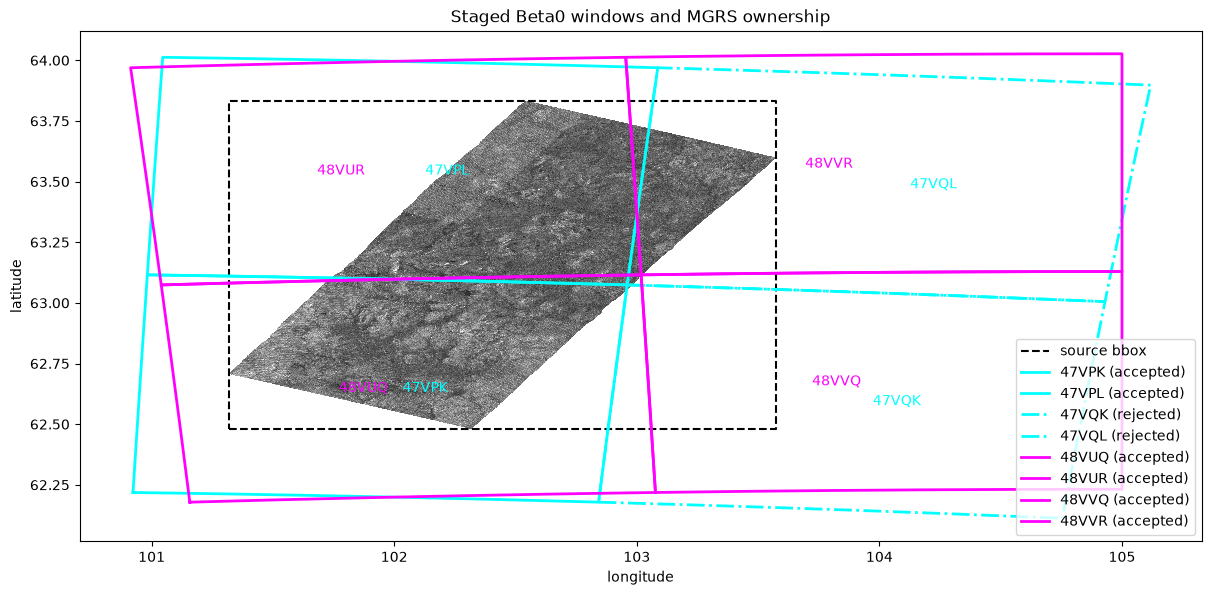

In [24]:
def geographic_outline(grid, points=64):
    """Return a densified exact TileGrid perimeter in longitude and latitude."""
    xmin, ymin, xmax, ymax = grid.bounds
    edge = np.linspace(0, 1, points)
    x = np.concatenate(
        (
            xmin + (xmax - xmin) * edge,
            np.full(points, xmax),
            xmax - (xmax - xmin) * edge,
            np.full(points, xmin),
        )
    )
    y = np.concatenate(
        (
            np.full(points, ymin),
            ymin + (ymax - ymin) * edge,
            np.full(points, ymax),
            ymax - (ymax - ymin) * edge,
        )
    )
    return Transformer.from_crs(grid.crs, "EPSG:4326", always_xy=True).transform(x, y)


fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)
with open_raster(source.beta0_tiff) as dataset:
    for grid in accepted:
        window = windows[grid.tile_id]
        beta0 = dataset.read(1, window=window, masked=True).astype("float32")
        window_longitude, window_latitude = geometry_coordinates(
            longitude, latitude, coordinates, metadata, window
        )
        step = max(1, int(np.ceil(max(beta0.shape) / 800)))
        ax.pcolormesh(
            window_longitude[::step, ::step],
            window_latitude[::step, ::step],
            beta0[::step, ::step],
            shading="auto",
            cmap="gray",
            alpha=0.65,
            vmin=0,
            vmax=1.5,
        )

west, south, east, north = source.bbox
ax.plot(
    [west, east, east, west, west],
    [south, south, north, north, south],
    "k--",
    label="source bbox",
)
for grid in grids:
    color = "fuchsia" if "48" in grid.tile_id else "cyan"
    line_style = "-" if grid in accepted else "-."
    x, y = geographic_outline(grid)
    ax.plot(
        x,
        y,
        color=color,
        linestyle=line_style,
        linewidth=2,
        label=f"{grid.tile_id} ({'accepted' if grid in accepted else 'rejected'})",
    )
    fuzz = 1 if "47" in grid.tile_id else -1
    ax.text(
        np.mean(x) + fuzz * 0.2,
        np.mean(y),
        grid.tile_id,
        color=color,
        ha="center",
        va="center",
    )

ax.set(
    title="Staged Beta0 windows and MGRS ownership",
    xlabel="longitude",
    ylabel="latitude",
)
ax.legend(loc="best")
ax.set_aspect("equal")